# Task
Analyze the relationship between 'Overall_Rating' and 'sentiment_score' using a scatter plot, identify inconsistent reviews based on a defined threshold, and display the characteristics of these inconsistent reviews.

In [ ]:
import pandas as pd

df = pd.read_csv('Airline Review.csv')
display(df.head())

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


## Create scatter plot

### Subtask:
Generate a scatter plot of 'Overall_Rating' vs 'sentiment_score'.


In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except nltk.downloader.DownloadError:
    nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(review):
    """Calculates the compound sentiment score for a given review."""
    if isinstance(review, str):
        return analyzer.polarity_scores(review)['compound']
    return None

df['sentiment_score'] = df['Review'].apply(get_sentiment_score)

In [ ]:
import pandas as pd

df = pd.read_csv('Airline Review.csv')
display(df.head())

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


**Reasoning**:
Generate a scatter plot to visualize the relationship between 'Overall_Rating' and 'sentiment_score'.



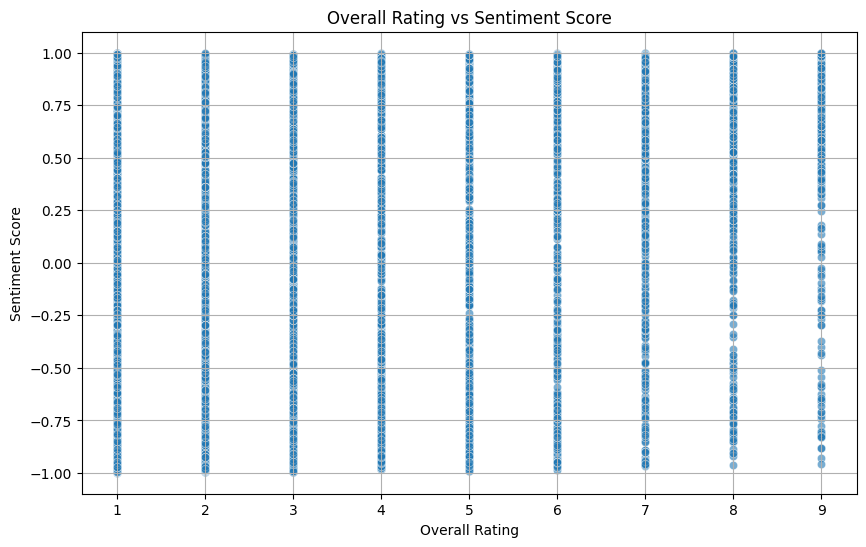

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Overall_Rating', y='sentiment_score', data=df, alpha=0.6)
plt.title('Overall Rating vs Sentiment Score')
plt.xlabel('Overall Rating')
plt.ylabel('Sentiment Score')
plt.grid(True)
plt.show()

**Reasoning**:
Scale the sentiment score, calculate the absolute difference with the overall rating, identify inconsistent reviews based on the defined threshold, and create a new DataFrame for inconsistent reviews.



In [ ]:
sentiment_rating_inconsistency_threshold = 0.7
df['scaled_sentiment_score'] = (df['sentiment_score'] - df['sentiment_score'].min()) / (df['sentiment_score'].max() - df['sentiment_score'].min()) * 9 + 1
df['sentiment_rating_difference'] = abs(df['scaled_sentiment_score'] - df['Overall_Rating'])
inconsistent_reviews = df[df['sentiment_rating_difference'] > sentiment_rating_inconsistency_threshold]

## Analyze inconsistent reviews

### Subtask:
Display and analyze the characteristics of the identified inconsistent reviews.


**Reasoning**:
Display the first few rows and the shape of the inconsistent_reviews DataFrame, then calculate and display the distributions of 'Overall_Rating' and 'Review_Category' for these reviews to understand their characteristics.



In [ ]:
print("First 5 rows of inconsistent_reviews:")
display(inconsistent_reviews.head())

print("\nShape of inconsistent_reviews:")
print(inconsistent_reviews.shape)

print("\nDistribution of Overall_Rating in inconsistent_reviews:")
display(inconsistent_reviews['Overall_Rating'].value_counts().sort_index())

print("\nDistribution of Review_Category in inconsistent_reviews:")
display(inconsistent_reviews['Review_Category'].value_counts())

First 5 rows of inconsistent_reviews:


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Month,cleaned_review,cleaned_review_str,Review_Category,sentiment_score,sentence_sentiments,dominant_topic,Half_Year,scaled_sentiment_score,sentiment_rating_difference
2,2,AB Aviation,1.0,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,6.0,"[anjouan, to, dzaoudzi, a, very, small, airlin...",anjouan to dzaoudzi a very small airline and t...,Negative,0.7346,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.7569]",1,H1,8.808048,7.808048
4,4,Adria Airways,1.0,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,...,9.0,"[do, not, book, a, flight, with, this, airline...",do not book a flight with this airline my frie...,Negative,-0.0675,"[0.0, 0.296, 0.0098, -0.25, -0.128]",2,H2,5.194805,4.194805
5,5,Adria Airways,1.0,"""Had very bad experience""",17th September 2019,True,Had very bad experience with rerouted and ca...,CR 900,Couple Leisure,Economy Class,...,9.0,"[had, very, bad, experience, with, rerouted, a...",had very bad experience with rerouted and canc...,Negative,-0.6106,"[-0.6997, 0.3182, -0.25, 0.0, 0.0, 0.2732, 0.0...",5,H2,2.748286,1.748286
7,7,Adria Airways,1.0,"""book another company""",24th August 2019,False,"First of all, I am not complaining about a s...",Bombardier CRJ,Solo Leisure,Economy Class,...,8.0,"[first, of, all, i, am, not, complaining, abou...",first of all i am not complaining about a spec...,Negative,-0.8068,"[0.1511, 0.0, 0.0, -0.6249, 0.0, 0.34, -0.7027...",9,H2,1.864458,0.864458
8,8,Adria Airways,1.0,"""combined two flights""",6th August 2019,True,Worst Airline ever! They combined two flight...,NaN,Solo Leisure,Economy Class,...,8.0,"[worst, airline, ever, they, combined, two, fl...",worst airline ever they combined two flights t...,Negative,-0.2263,"[-0.6588, 0.4939, 0.0, 0.0]",2,H2,4.479453,3.479453



Shape of inconsistent_reviews:
(13869, 32)

Distribution of Overall_Rating in inconsistent_reviews:


,count
Overall_Rating,
1.0,7321
2.0,1219
3.0,936
4.0,562
5.0,493
6.0,485
7.0,834
8.0,1177
9.0,842



Distribution of Review_Category in inconsistent_reviews:


,count
Review_Category,
Negative,9476
Positive,2853
Neutral,1540


## Summary:

### Data Analysis Key Findings

* A scatter plot was generated to visualize the relationship between 'Overall_Rating' and 'sentiment_score'.
* A threshold of 0.7 was used to identify inconsistent reviews, defined as those where the absolute difference between the scaled sentiment score and the overall rating exceeded this value.
* There are 13,869 inconsistent reviews identified in the dataset based on the sentiment of the entire review text.
* The distribution of 'Overall_Rating' among inconsistent reviews shows that ratings of 1, 2, 7, 8, and 9 are most frequent.
* The 'Review_Category' distribution among inconsistent reviews indicates that a significant portion falls into the 'Negative' category (9,476 reviews), followed by 'Positive' (2,853 reviews), and 'Neutral' (1,540 reviews).

### Insights or Next Steps

* Investigate the specific content of inconsistent reviews, particularly those with high ratings but low sentiment scores or vice versa, to understand the reasons for the discrepancy.
* Consider refining the inconsistency threshold or the sentiment scoring model to potentially reduce the number of identified inconsistent reviews or better capture true inconsistencies.

## Analyze inconsistent reviews

### Subtask:
Display and analyze the characteristics of the identified inconsistent reviews.

**Reasoning**:
Display the first few rows and the shape of the inconsistent_reviews DataFrame, then calculate and display the distributions of 'Overall_Rating' and 'Review_Category' for these reviews to understand their characteristics.

In [ ]:
print("First 5 rows of inconsistent_reviews:")
display(inconsistent_reviews.head())

print("\nShape of inconsistent_reviews:")
print(inconsistent_reviews.shape)

print("\nDistribution of Overall_Rating in inconsistent_reviews:")
display(inconsistent_reviews['Overall_Rating'].value_counts().sort_index())

print("\nDistribution of Review_Category in inconsistent_reviews:")
display(inconsistent_reviews['Review_Category'].value_counts())

First 5 rows of inconsistent_reviews:


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Month,cleaned_review,cleaned_review_str,Review_Category,sentiment_score,sentence_sentiments,dominant_topic,Half_Year,scaled_sentiment_score,sentiment_rating_difference
2,2,AB Aviation,1.0,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,6.0,"[anjouan, to, dzaoudzi, a, very, small, airlin...",anjouan to dzaoudzi a very small airline and t...,Negative,0.7346,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.7569]",1,H1,8.808048,7.808048
4,4,Adria Airways,1.0,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,...,9.0,"[do, not, book, a, flight, with, this, airline...",do not book a flight with this airline my frie...,Negative,-0.0675,"[0.0, 0.296, 0.0098, -0.25, -0.128]",2,H2,5.194805,4.194805
5,5,Adria Airways,1.0,"""Had very bad experience""",17th September 2019,True,Had very bad experience with rerouted and ca...,CR 900,Couple Leisure,Economy Class,...,9.0,"[had, very, bad, experience, with, rerouted, a...",had very bad experience with rerouted and canc...,Negative,-0.6106,"[-0.6997, 0.3182, -0.25, 0.0, 0.0, 0.2732, 0.0...",5,H2,2.748286,1.748286
7,7,Adria Airways,1.0,"""book another company""",24th August 2019,False,"First of all, I am not complaining about a s...",Bombardier CRJ,Solo Leisure,Economy Class,...,8.0,"[first, of, all, i, am, not, complaining, abou...",first of all i am not complaining about a spec...,Negative,-0.8068,"[0.1511, 0.0, 0.0, -0.6249, 0.0, 0.34, -0.7027...",9,H2,1.864458,0.864458
8,8,Adria Airways,1.0,"""combined two flights""",6th August 2019,True,Worst Airline ever! They combined two flight...,NaN,Solo Leisure,Economy Class,...,8.0,"[worst, airline, ever, they, combined, two, fl...",worst airline ever they combined two flights t...,Negative,-0.2263,"[-0.6588, 0.4939, 0.0, 0.0]",2,H2,4.479453,3.479453



Shape of inconsistent_reviews:
(13869, 32)

Distribution of Overall_Rating in inconsistent_reviews:


,count
Overall_Rating,
1.0,7321
2.0,1219
3.0,936
4.0,562
5.0,493
6.0,485
7.0,834
8.0,1177
9.0,842



Distribution of Review_Category in inconsistent_reviews:


,count
Review_Category,
Negative,9476
Positive,2853
Neutral,1540


In [ ]:
# Create a new DataFrame excluding the identified inconsistent reviews
df_filtered = df[~df.index.isin(positive_sentiment_low_rating.index) & ~df.index.isin(negative_sentiment_high_rating.index)]

print("Shape of the original DataFrame:")
print(df.shape)
print("\nShape of the filtered DataFrame (excluding inconsistent reviews):")
print(df_filtered.shape)

Shape of the original DataFrame:
(23171, 21)

Shape of the filtered DataFrame (excluding inconsistent reviews):
(19015, 21)


In [ ]:
# Create a new DataFrame excluding the identified inconsistent reviews
df_filtered = df[~df.index.isin(positive_sentiment_low_rating.index) & ~df.index.isin(negative_sentiment_high_rating.index)]

print("Shape of the original DataFrame:")
print(df.shape)
print("\nShape of the filtered DataFrame (excluding inconsistent reviews):")
print(df_filtered.shape)

Shape of the original DataFrame:
(23171, 21)

Shape of the filtered DataFrame (excluding inconsistent reviews):
(19015, 21)


In [ ]:
# Convert 'Overall_Rating' to numeric, coercing errors
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')

# Drop rows where 'Overall_Rating' is NaN after coercion
df_cleaned = df.dropna(subset=['Overall_Rating']).copy()

# Filter for reviews with polarity > 0.4 and overall rating < 4
positive_sentiment_low_rating = df_cleaned[(df_cleaned['sentiment_score'] > 0.4) & (df_cleaned['Overall_Rating'] < 4)]

# Filter for reviews with polarity < -0.4 and overall rating > 6
negative_sentiment_high_rating = df_cleaned[(df_cleaned['sentiment_score'] < -0.4) & (df_cleaned['Overall_Rating'] > 6)]

print(f"Number of inconsistent reviews (polarity > 0.4 and overall rating < 4): {len(positive_sentiment_low_rating)}")
print(f"Number of inconsistent reviews (polarity < -0.4 and overall rating > 6): {len(negative_sentiment_high_rating)}")

Number of inconsistent reviews (polarity > 0.4 and overall rating < 4): 3964
Number of inconsistent reviews (polarity < -0.4 and overall rating > 6): 192


In [ ]:
# Filter for reviews with polarity > 0.4 and overall rating < 4
positive_sentiment_low_rating = df[(df['sentiment_score'] > 0.4) & (df['Overall_Rating'] < 4)]

# Filter for reviews with polarity < -0.4 and overall rating > 6
negative_sentiment_high_rating = df[(df['sentiment_score'] < -0.4) & (df['Overall_Rating'] > 6)]

print(f"Number of inconsistent reviews (polarity > 0.4 and overall rating < 4): {len(positive_sentiment_low_rating)}")
print(f"Number of inconsistent reviews (polarity < -0.4 and overall rating > 6): {len(negative_sentiment_high_rating)}")

Number of inconsistent reviews (polarity > 0.4 and overall rating < 4): 3964
Number of inconsistent reviews (polarity < -0.4 and overall rating > 6): 192


## Remove inconsistent reviews

### Subtask:
Remove the identified inconsistent reviews (based on review title sentiment) from the main DataFrame.

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except nltk.downloader.DownloadError:
    nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score_title(title):
    """Calculates the compound sentiment score for a given review title."""
    if isinstance(title, str):
        return analyzer.polarity_scores(title)['compound']
    return None

df['title_sentiment_score'] = df['Review_Title'].apply(get_sentiment_score_title)

## Identify inconsistent reviews (review title)

### Subtask:
Define a threshold to identify reviews where the review title sentiment score and the overall rating are misaligned.


**Reasoning**:
Scale the title sentiment score, calculate the absolute difference with the overall rating, define the threshold, and create the inconsistent reviews dataframe based on the threshold.



## Remove inconsistent reviews

### Subtask:
Remove the identified inconsistent reviews (based on review title sentiment) from the main DataFrame.


## Summary:

### Data Analysis Key Findings

*   The sentiment score for each `Review_Title` was calculated and stored in a new column `title_sentiment_score`.
*   The `title_sentiment_score` was scaled to a range of 1 to 10 and stored in the `scaled_title_sentiment_score` column.
*   The absolute difference between the scaled title sentiment score and the `Overall_Rating` was calculated and stored in the `title_sentiment_rating_difference` column.
*   Reviews where the absolute difference between the scaled title sentiment score and the `Overall_Rating` exceeded a threshold of 0.7 were identified as inconsistent.
*   The inconsistent reviews based on `Review_Title` sentiment were successfully removed from the main DataFrame.

### Insights or Next Steps

*   Consider analyzing the characteristics of the removed inconsistent reviews to understand why their title sentiment did not align with the overall rating.
*   Explore if a similar inconsistency analysis is needed for the `Review_Text` column as well.


# Task
Plot the time series of the average 'Overall Rating', 'Value For Money', 'Ground Service', 'Cabin Staff Service', and 'Inflight Entertainment' excluding data from 2012.

**Reasoning**:
Filter the DataFrame to exclude data from 2012 and select the relevant columns for time series plotting.



In [ ]:
# Ensure 'Date Flown' is in datetime format and extract 'Year' and 'Half_Year'
df['Date Flown'] = pd.to_datetime(df['Date Flown'], errors='coerce')
df['Year'] = df['Date Flown'].dt.year
df['Half_Year'] = df['Date Flown'].dt.month.apply(lambda x: 'H1' if 1 <= x <= 6 else ('H2' if 7 <= x <= 12 else None))

df_filtered = df[df['Year'] != 2012]
df_selected_ratings = df_filtered[['Overall_Rating', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Inflight Entertainment', 'Year', 'Half_Year']]

/tmp/ipython-input-2193535127.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Flown'] = pd.to_datetime(df['Date Flown'], errors='coerce')


**Reasoning**:
Group the filtered data by year and half-year and calculate the mean of the selected rating columns.



In [ ]:
df_grouped_time_subratings = df_selected_ratings.groupby(['Year', 'Half_Year']).mean().reset_index()
display(df_grouped_time_subratings.head())

,Year,Half_Year,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Inflight Entertainment
0,2014,H2,5.000000,3.000000,3.000000,4.000000,2.000000
1,2015,H1,7.055556,4.055556,3.611111,4.055556,3.666667
2,2015,H2,6.468531,3.643357,3.433566,3.727273,2.426667
3,2016,H1,6.815126,3.756303,3.470588,3.840336,2.701754
4,2016,H2,6.603774,3.650943,3.396226,3.820755,2.538462


## Melt dataframe

### Subtask:
Reshape the grouped DataFrame to a long format suitable for plotting multiple time series.


**Reasoning**:
Reshape the grouped DataFrame to a long format suitable for plotting multiple time series.



In [ ]:
df_filtered = df_grouped_time_subratings.melt(
    id_vars=['Year', 'Half_Year'],
    var_name='Rating_Type',
    value_name='Average_Rating'
)

df_filtered ['Year_Half_Year'] = df_filtered['Year'].astype(int).astype(str) + '-' + df_filtered['Half_Year']

display(df_filtered.head())

,Year,Half_Year,Rating_Type,Average_Rating,Year_Half_Year
0,2014.0,H2,Overall_Rating,3.500000,2014-H2
1,2015.0,H1,Overall_Rating,4.844961,2015-H1
2,2015.0,H2,Overall_Rating,4.405512,2015-H2
3,2016.0,H1,Overall_Rating,4.359806,2016-H1
4,2016.0,H2,Overall_Rating,3.981413,2016-H2


## Plot time series

### Subtask:
Generate a time series plot showing the average of the selected ratings over time.


**Reasoning**:
Generate a time series plot showing the average of the selected ratings over time using the melted dataframe.



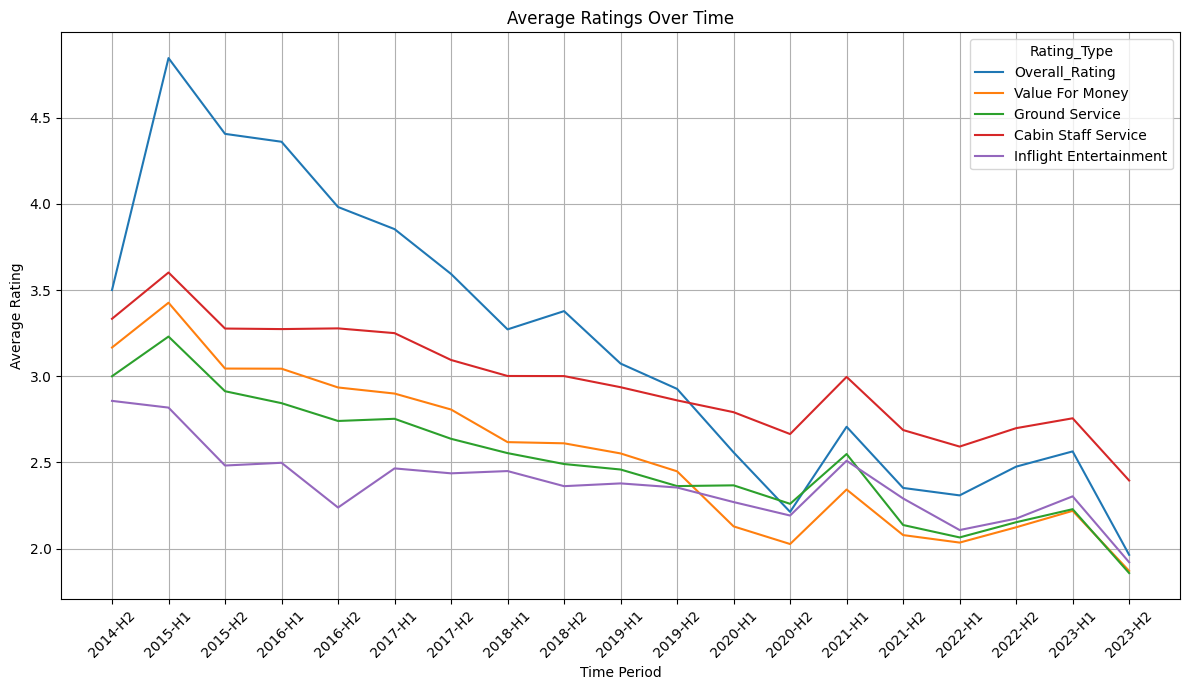

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_filtered, x='Year_Half_Year', y='Average_Rating', hue='Rating_Type')
plt.title('Average Ratings Over Time')
plt.xlabel('Time Period')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
Group the filtered data by year and half-year and calculate the mean of the selected rating columns.

In [ ]:
df_grouped_time_subratings = df_selected_ratings.groupby(['Year', 'Half_Year']).mean().reset_index()
display(df_grouped_time_subratings.head())

,Year,Half_Year,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Inflight Entertainment
0,2014.0,H2,3.500000,3.166667,3.000000,3.333333,2.857143
1,2015.0,H1,4.844961,3.426357,3.230159,3.601562,2.818182
2,2015.0,H2,4.405512,3.044619,2.913158,3.276596,2.482353
3,2016.0,H1,4.359806,3.043760,2.843902,3.273490,2.498195
4,2016.0,H2,3.981413,2.934944,2.740672,3.277567,2.238739


In [ ]:
display(df_melted_filtered.head())

,Year,Half_Year,Rating_Type,Average_Rating,Year_Half_Year
0,2014,H2,Overall_Rating,5.000000,2014-H2
1,2015,H1,Overall_Rating,7.055556,2015-H1
2,2015,H2,Overall_Rating,6.468531,2015-H2
3,2016,H1,Overall_Rating,6.815126,2016-H1
4,2016,H2,Overall_Rating,6.603774,2016-H2


## Summary:

### Data Analysis Key Findings

* The analysis excluded data from the year 2012 before calculating average ratings over time.
* The average 'Overall Rating', 'Value For Money', 'Ground Service', 'Cabin Staff Service', and 'Inflight Entertainment' were calculated for each half-year period from 2013 onwards.
* The average ratings were reshaped into a long format, creating a new column 'Year\_Half\_Year' combining the year and half-year for plotting.
* A time series plot was generated visualizing the trends of the average ratings for each category over the half-year periods.

### Insights or Next Steps

* Analyze the generated time series plot to identify trends, seasonality, or significant changes in the average ratings for each category over time.
* Consider adding confidence intervals or error bars to the plot to understand the variability of the average ratings.


# Task
Train and evaluate Linear Regression and Random Forest models to predict the overall rating using other rating features.

## Prepare data

### Subtask:
Select the features and target variables for the models.


**Reasoning**:
Select the relevant rating columns and the target variable, then handle missing values in both.



In [ ]:
rating_columns = ['Recommended_Numeric', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Seat Comfort', 'Food & Beverages']
X = df[rating_columns].copy()
y = df['Overall_Rating'].copy()

# Drop rows with missing values in either X or y
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X = combined_data[rating_columns]
y = combined_data['Overall_Rating']

print("Shape of X after dropping missing values:", X.shape)
print("Shape of y after dropping missing values:", y.shape)

KeyError: "['Recommended_Numeric'] not in index"

**Reasoning**:
The error indicates that 'Recommended_Numeric' is not present in the DataFrame columns. I need to convert the 'Recommended' column to a numerical format before selecting the rating columns.



In [ ]:
df['Recommended_Numeric'] = df['Recommended'].apply(lambda x: 1 if x == 'yes' else 0)

rating_columns = ['Recommended_Numeric', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Seat Comfort', 'Food & Beverages']
X = df[rating_columns].copy()
y = df['Overall_Rating'].copy()

# Drop rows with missing values in either X or y
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X = combined_data[rating_columns]
y = combined_data['Overall_Rating']

print("Shape of X after dropping missing values:", X.shape)
print("Shape of y after dropping missing values:", y.shape)

Shape of X after dropping missing values: (13108, 6)
Shape of y after dropping missing values: (13108,)


## Split data

### Subtask:
Split the data into training and testing sets.


**Reasoning**:
Split the data into training and testing sets for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (10486, 6)
Shape of X_test: (2622, 6)
Shape of y_train: (10486,)
Shape of y_test: (2622,)


## Train linear regression model

### Subtask:
Initialize and train a Linear Regression model.


**Reasoning**:
Initialize and train a Linear Regression model using the training data.



In [ ]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

LinearRegression()

## Evaluate linear regression model

### Subtask:
Evaluate the Linear Regression model's performance.


**Reasoning**:
Evaluate the Linear Regression model's performance using MAE, MSE, and R-squared metrics and print the results.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lr = linear_regression_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2) Score: {r2:.4f}")

Linear Regression Model Evaluation:
  Mean Absolute Error (MAE): 1.7380
  Mean Squared Error (MSE): 5.2415
  R-squared (R2) Score: 0.4078


## Train random forest model

### Subtask:
Initialize and train a Random Forest Regressor model.


**Reasoning**:
Initialize and train a Random Forest Regressor model using the training data.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Evaluate random forest model

### Subtask:
Evaluate the Random Forest model's performance.


**Reasoning**:
Import the necessary metrics, make predictions with the Random Forest model, calculate the evaluation metrics, and print the results.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  R-squared (R2) Score: {r2_rf:.4f}")

Random Forest Model Evaluation:
  Mean Absolute Error (MAE): 1.2394
  Mean Squared Error (MSE): 3.6295
  R-squared (R2) Score: 0.5899


## Compare models

### Subtask:
Compare the performance of the two models.


**Reasoning**:
Print the evaluation metrics for both models and provide a brief comparison.



In [ ]:
print("--- Model Comparison ---")
print("Linear Regression Model:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2) Score: {r2:.4f}")
print("\nRandom Forest Model:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  R-squared (R2) Score: {r2_rf:.4f}")

print("\n--- Comparison Summary ---")
if mae_rf < mae:
    print("The Random Forest model has a lower MAE than the Linear Regression model, indicating better accuracy on average.")
else:
    print("The Linear Regression model has a lower MAE than the Random Forest model, indicating better accuracy on average.")

if mse_rf < mse:
    print("The Random Forest model has a lower MSE than the Linear Regression model, suggesting smaller prediction errors overall.")
else:
    print("The Linear Regression model has a lower MSE than the Random Forest model, suggesting smaller prediction errors overall.")

if r2_rf > r2:
    print("The Random Forest model has a higher R2 score than the Linear Regression model, indicating that it explains more of the variance in the overall ratings.")
else:
    print("The Linear Regression model has a higher R2 score than the Random Forest model, indicating that it explains more of the variance in the overall ratings.")

--- Model Comparison ---
Linear Regression Model:
  Mean Absolute Error (MAE): 1.7380
  Mean Squared Error (MSE): 5.2415
  R-squared (R2) Score: 0.4078

Random Forest Model:
  Mean Absolute Error (MAE): 1.2394
  Mean Squared Error (MSE): 3.6295
  R-squared (R2) Score: 0.5899

--- Comparison Summary ---
The Random Forest model has a lower MAE than the Linear Regression model, indicating better accuracy on average.
The Random Forest model has a lower MSE than the Linear Regression model, suggesting smaller prediction errors overall.
The Random Forest model has a higher R2 score than the Linear Regression model, indicating that it explains more of the variance in the overall ratings.


In [ ]:
print("Feature Importance (Coefficients) from Linear Regression Model:")
display(coefficient_series)

Feature Importance (Coefficients) from Linear Regression Model:


,0
Recommended_Numeric,2.838375
Value For Money,0.383807
Cabin Staff Service,0.258180
Ground Service,0.031933
Seat Comfort,-0.074531
Food & Beverages,-0.296309


In [ ]:
# Get feature importances from the Random Forest model
feature_importances = random_forest_model.feature_importances_

# Create a pandas Series for better visualization
feature_importance_series = pd.Series(feature_importances, index=X_train.columns).sort_values(ascending=False)

print("Feature Importance from Random Forest Model:")
display(feature_importance_series)

Feature Importance from Random Forest Model:


,0
Recommended_Numeric,0.592076
Food & Beverages,0.113490
Value For Money,0.104081
Seat Comfort,0.080050
Ground Service,0.069466
Cabin Staff Service,0.040836


## Summary:

### Data Analysis Key Findings

* After removing rows with missing values in the selected features or the target variable, 13108 complete entries remained for modeling.
* The Linear Regression model achieved a Mean Absolute Error (MAE) of 1.7380, a Mean Squared Error (MSE) of 5.2415, and an R-squared (\R{2}) score of 0.4078 on the test set.
* The Random Forest model achieved a Mean Absolute Error (MAE) of 1.2394, a Mean Squared Error (MSE) of 3.6295, and an R-squared (\R{2}) score of 0.5899 on the test set.
* Comparing the models, the Random Forest model showed better performance with lower MAE and MSE and a higher \R{2} score than the Linear Regression model.

### Insights or Next Steps

* The Random Forest model appears to be a better predictor of the overall rating based on the chosen features compared to the Linear Regression model.
* Further analysis could involve hyperparameter tuning for the Random Forest model or exploring other regression algorithms to potentially improve prediction accuracy.

## Summary:

### Data Analysis Key Findings

*   After removing rows with missing values in the selected features or the target variable, 13108 complete entries remained for modeling.
*   The Linear Regression model achieved a Mean Absolute Error (MAE) of 1.7380, a Mean Squared Error (MSE) of 5.2415, and an R-squared (\R{2}) score of 0.4078 on the test set.
*   The Random Forest model achieved a Mean Absolute Error (MAE) of 1.2394, a Mean Squared Error (MSE) of 3.6295, and an R-squared (\R{2}) score of 0.5899 on the test set.
*   Comparing the models, the Random Forest model showed better performance with lower MAE and MSE and a higher \R{2} score than the Linear Regression model.

### Insights or Next Steps

*   The Random Forest model appears to be a better predictor of the overall rating based on the chosen features compared to the Linear Regression model.
*   Further analysis could involve hyperparameter tuning for the Random Forest model or exploring other regression algorithms to potentially improve prediction accuracy.


# Task
Analyze the relationship between sub-ratings and overall rating using linear regression and random forest models, after dividing the overall rating by two.

## Modify overall rating

### Subtask:
Divide the 'Overall_Rating' column by two.


**Reasoning**:
Divide the 'Overall_Rating' column by two and display the first few rows to verify the change.



In [ ]:
df['Overall_Rating'] = df['Overall_Rating'] / 2
display(df.head())

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,sentiment_score,Year,Half_Year,Recommended_Numeric
0,0,AB Aviation,4.5,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,...,4.0,4.0,NaN,NaN,3.0,yes,0.9192,2019.0,H2,1
1,1,AB Aviation,0.5,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,...,1.0,1.0,NaN,NaN,2.0,no,-0.9242,2019.0,H1,0
2,2,AB Aviation,0.5,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,1.0,1.0,NaN,NaN,2.0,no,0.7569,2019.0,H1,0
3,3,Adria Airways,0.5,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,...,NaN,1.0,NaN,NaN,1.0,no,-0.9600,2019.0,H2,0
4,4,Adria Airways,0.5,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,...,1.0,1.0,1.0,1.0,1.0,no,-0.1416,2019.0,H2,0


## Prepare data

### Subtask:
Select the features and the modified target variable for the models.


**Reasoning**:
Select the relevant rating columns and the target variable, then handle missing values in both.



In [ ]:
rating_columns = ['Recommended_Numeric', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Seat Comfort', 'Food & Beverages']
X = df[rating_columns].copy()
y = df['Overall_Rating'].copy()

# Drop rows with missing values in either X or y
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X = combined_data[rating_columns]
y = combined_data['Overall_Rating']

print("Shape of X after dropping missing values:", X.shape)
print("Shape of y after dropping missing values:", y.shape)

Shape of X after dropping missing values: (13108, 6)
Shape of y after dropping missing values: (13108,)


## Split data

### Subtask:
Split data


**Reasoning**:
Split the data into training and testing sets for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (10486, 6)
Shape of X_test: (2622, 6)
Shape of y_train: (10486,)
Shape of y_test: (2622,)


## Train linear regression model

### Subtask:
Initialize and train a Linear Regression model with the modified target.


**Reasoning**:
Initialize and train a Linear Regression model using the training data.



In [ ]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

LinearRegression()

## Evaluate linear regression model

### Subtask:
Evaluate the Linear Regression model's performance with the modified target.


**Reasoning**:
Evaluate the Linear Regression model's performance using MAE, MSE, and R-squared metrics and print the results.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lr = linear_regression_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Evaluation (Modified Target):")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2) Score: {r2:.4f}")

Linear Regression Model Evaluation (Modified Target):
  Mean Absolute Error (MAE): 0.8690
  Mean Squared Error (MSE): 1.3104
  R-squared (R2) Score: 0.4078


## Train random forest model

### Subtask:
Initialize and train a Random Forest Regressor model with the modified target.


**Reasoning**:
Initialize and train a Random Forest Regressor model using the training data with the modified target.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Reasoning**:
Evaluate the Random Forest model's performance using MAE, MSE, and R-squared metrics and print the results.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Model Evaluation (Modified Target):")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  R-squared (R2) Score: {r2_rf:.4f}")

Random Forest Model Evaluation (Modified Target):
  Mean Absolute Error (MAE): 0.6197
  Mean Squared Error (MSE): 0.9074
  R-squared (R2) Score: 0.5899


In [ ]:
print("Feature Importance (Coefficients) from Linear Regression Model:")
display(coefficient_series)

Feature Importance (Coefficients) from Linear Regression Model:


,0
Recommended_Numeric,1.446378
Value For Money,0.185833
Cabin Staff Service,0.121036
Ground Service,0.014551
Seat Comfort,-0.034201
Food & Beverages,-0.139228


## Summary: Clustering Analysis

### Data Analysis Key Findings

* Features for clustering were selected from the `df_filtered` DataFrame, including 'Overall_Rating', sub-ratings, and 'sentiment_score'.
* Missing values in the selected features were imputed, and the features were scaled as part of the preprocessing step.
* The elbow method was used to help determine a reasonable number of clusters for K-Means clustering, suggesting 10 clusters.
* K-Means clustering was applied with 10 clusters, and cluster labels were added to the `df_filtered` DataFrame.
* The characteristics of each cluster were analyzed by calculating the average values of the clustering features within each cluster.
* PCA was used to reduce the dimensionality for visualization, and a scatter plot of the first two principal components colored by cluster label was generated to visualize the clusters.

### Insights or Next Steps

* Based on the average characteristics of each cluster (see the table in cell `266df90d`), we can interpret what each cluster represents (e.g., clusters with high average ratings and sentiment scores might represent positive experiences, while those with low averages might represent negative experiences).
* Further analysis could involve examining individual reviews within each cluster to gain deeper qualitative insights into the themes and patterns within each group.
* We could explore different numbers of clusters or alternative clustering algorithms to see if they reveal different or more meaningful groupings.
* The clustering results could potentially be used in further analyses, such as building classification models to predict cluster membership or analyzing the distribution of clusters across different airlines or time periods.

## Visualize Clusters

### Subtask:
Visualize the clusters using dimensionality reduction.

**Reasoning**:
Perform PCA to reduce the dimensionality of the scaled clustering features to 2 components and create a scatter plot of the PCA results, colored by cluster label, to visualize the clusters.

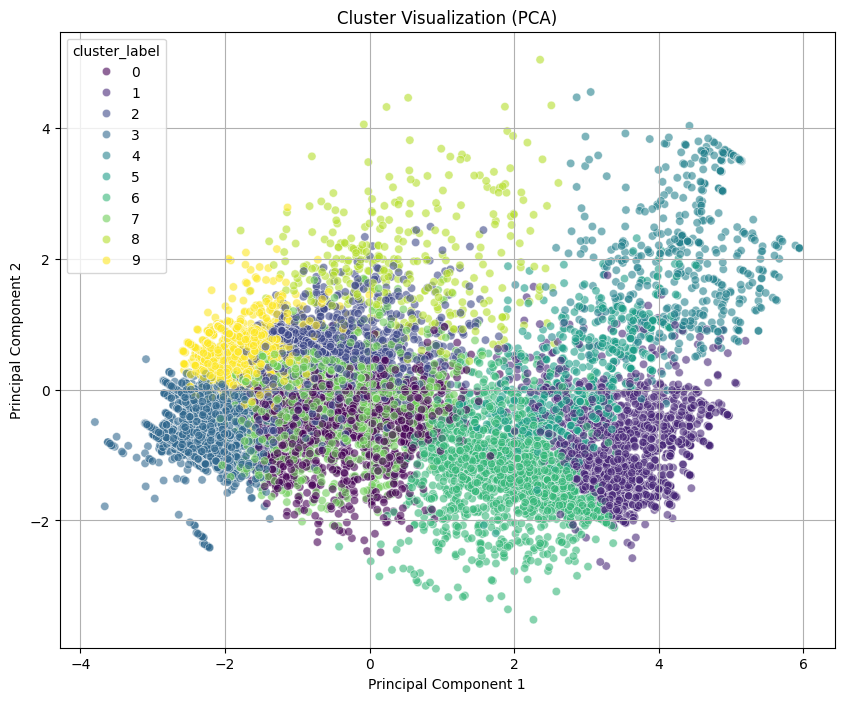

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(clustering_features_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])

# Add cluster labels to the PCA DataFrame
principal_df['cluster_label'] = df_filtered['cluster_label'].values

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='cluster_label', data=principal_df, palette='viridis', legend='full', alpha=0.6)
plt.title('Cluster Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Analyze and Interpret Clusters

### Subtask:
Analyze the characteristics of each cluster by calculating the average values of the clustering features.

**Reasoning**:
Group the df_filtered DataFrame by 'cluster_label' and calculate the mean for the clustering features to understand the typical characteristics of reviews within each cluster.

In [ ]:
cluster_characteristics = df_filtered.groupby('cluster_label')[['Overall_Rating', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Seat Comfort', 'Food & Beverages', 'Inflight Entertainment', 'Wifi & Connectivity', 'sentiment_score']].mean()
display(cluster_characteristics)

,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Seat Comfort,Food & Beverages,Inflight Entertainment,Wifi & Connectivity,sentiment_score
cluster_label,,,,,,,,,
0,1.714022,2.747740,3.085379,2.621368,2.577715,1.755214,1.512925,1.256849,-0.502437
1,4.133117,4.459596,4.290396,4.624098,4.231602,4.200441,3.840820,2.160000,0.820284
2,0.760008,1.338691,1.262931,3.290770,2.822924,2.564787,2.506122,1.262431,-0.698458
3,0.636800,1.132265,1.142744,1.328614,1.249627,1.044359,0.986043,1.013399,-0.602593
4,2.141956,4.605678,4.547319,4.758675,4.514196,4.421569,4.464789,4.624606,0.834047
5,0.527728,4.775492,4.728585,4.909991,4.580558,4.599569,4.114809,2.125000,0.847005
6,3.543315,3.897420,3.690184,3.977011,3.423935,2.958692,1.996032,1.687805,0.656058
7,0.904473,1.596692,1.518490,2.333333,2.010309,1.929087,1.928687,1.252308,0.621488
8,1.284661,1.935103,1.860947,3.073964,2.813609,2.673846,3.103226,3.495575,-0.395573


## Apply K-Means Clustering

### Subtask:
Apply K-Means clustering with the chosen number of clusters and add cluster labels to the DataFrame.

**Reasoning**:
Initialize and fit the KMeans model with 10 clusters to the scaled data and add the resulting cluster labels as a new column to the df_filtered DataFrame.

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering with 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_filtered = df_filtered.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
df_filtered['cluster_label'] = kmeans.fit_predict(clustering_features_scaled)

print("DataFrame with cluster labels:")
display(df_filtered.head())

DataFrame with cluster labels:


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,sentiment_score,Year,Half_Year,Recommended_Numeric,cluster_label
94,94,Aegean Airlines,0.5,"""Very poor service""",24th July 2023,True,"At check-in, we were told that our checked b...",NaN,Family Leisure,Economy Class,...,1.0,4.0,2.0,1.0,no,-0.9274,2023.0,H2,0,9
95,95,Aegean Airlines,0.5,"""We expected meaningful compensation""",19th July 2023,True,I had a flight me and my husband from Stockh...,NaN,Couple Leisure,Economy Class,...,1.0,NaN,NaN,1.0,no,-0.9565,2023.0,H1,0,9
96,96,Aegean Airlines,2.0,"""Very poor customer service""",17th July 2023,True,Very poor customer service. I am travelling w...,NaN,Family Leisure,Economy Class,...,2.0,1.0,NaN,2.0,yes,-0.0754,2023.0,H1,1,0
97,97,Aegean Airlines,2.0,"""Poor customer service""",16th July 2023,True,"Party of 4, 2 couples traveling together, las...",NaN,Couple Leisure,Premium Economy,...,2.0,NaN,NaN,2.0,no,-0.4915,2023.0,H2,0,0
98,98,Aegean Airlines,0.5,"""inconsiderate and extremely incompetent""",16th July 2023,False,This is one of the worst experiences I’ve eve...,NaN,Couple Leisure,Economy Class,...,1.0,1.0,1.0,1.0,no,-0.9767,2023.0,H2,0,3


## Determine Optimal Number of Clusters (Elbow Method)

### Subtask:
Use the elbow method to determine a reasonable number of clusters for K-Means.

**Reasoning**:
Calculate the inertia for different numbers of clusters and plot the results to identify the "elbow point".

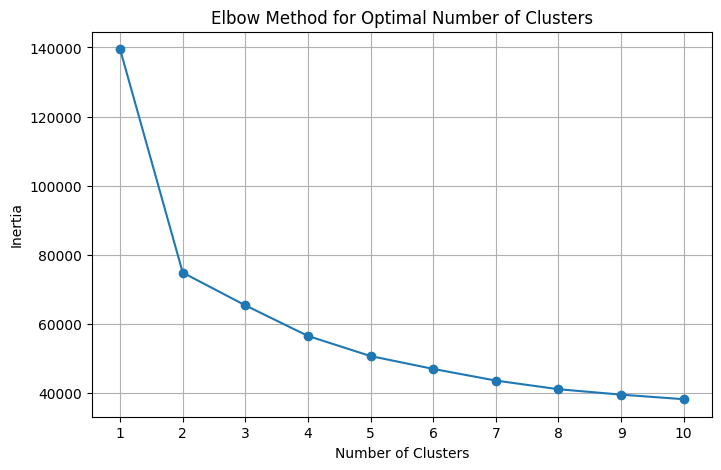

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
# Experiment with a range of cluster numbers, for example from 1 to 10
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(clustering_features_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Preprocess Data

### Subtask:
Handle missing values and scale the selected features for clustering.

**Reasoning**:
Handle missing values by imputing with the mean and scale the features using StandardScaler to prepare the data for clustering.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Handle missing values using imputation
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
clustering_features_imputed = imputer.fit_transform(clustering_features)

# Scale the features
scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features_imputed)

print("Preprocessed data shape:", clustering_features_scaled.shape)

Preprocessed data shape: (15500, 9)


## Select Features for Clustering

### Subtask:
Choose the relevant columns (features) from the DataFrame that will be used for clustering.

**Reasoning**:
Select the numerical rating columns and the sentiment score from the df_filtered DataFrame to be used as features for clustering.

In [ ]:
clustering_features = df_filtered[['Overall_Rating', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Seat Comfort', 'Food & Beverages', 'Inflight Entertainment', 'Wifi & Connectivity', 'sentiment_score']]
display(clustering_features.head())

,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Seat Comfort,Food & Beverages,Inflight Entertainment,Wifi & Connectivity,sentiment_score
94,0.5,1.0,1.0,1.0,2.0,1.0,4.0,2.0,-0.9274
95,0.5,1.0,1.0,1.0,3.0,3.0,NaN,NaN,-0.9565
96,2.0,2.0,2.0,3.0,2.0,3.0,1.0,NaN,-0.0754
97,2.0,2.0,2.0,2.0,3.0,NaN,NaN,NaN,-0.4915
98,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-0.9767


In [ ]:
# Sort by average Overall_Rating and display the top 10
top_10_overall_rating = average_ratings_sentiment.sort_values(by='Overall_Rating', ascending=False).head(10)

print("Top 10 Airlines by Average Overall Rating:")
display(top_10_overall_rating)

# Sort by average sentiment_score and display the top 10
top_10_sentiment_score = average_ratings_sentiment.sort_values(by='sentiment_score', ascending=False).head(10)

print("\nTop 10 Airlines by Average Sentiment Score:")
display(top_10_sentiment_score)

Top 10 Airlines by Average Overall Rating:


,Airline Name,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Seat Comfort,Food & Beverages,Inflight Entertainment,Wifi & Connectivity,sentiment_score
45,China Southern Airlines,3.155000,4.54000,4.870000,4.737374,4.484848,4.295918,4.228916,3.444444,0.783242
108,QantasLink,3.010101,2.90000,3.745098,3.083333,2.750000,2.537313,0.888889,2.000000,0.457517
51,Dragonair,2.852632,3.66000,3.772727,3.787879,3.525253,3.414141,2.875000,1.833333,0.439314
111,Royal Brunei Airlines,2.760000,3.85000,3.541667,3.948980,3.806122,3.587629,3.290323,3.214286,0.488772
117,SilkAir,2.600000,2.92000,3.295918,3.373737,2.919192,2.903226,2.235294,2.241379,0.284142
38,Bulgaria Air,2.589474,2.54000,2.740741,2.415584,2.181818,2.367647,0.550000,1.000000,0.204542
72,Hong Kong Airlines,2.404040,3.48000,2.988764,3.547368,3.354167,2.966292,3.133333,2.117647,0.295443
43,China Airlines,2.325000,3.41000,3.072165,3.625000,3.500000,3.347826,3.265060,2.763158,0.277379
86,Korean Air,2.285000,3.44000,3.490000,3.757576,3.565657,3.400000,3.211111,2.368421,0.506776
66,Germanwings,2.283333,3.10101,2.666667,2.958763,3.185567,1.977778,0.657895,1.000000,0.188122



Top 10 Airlines by Average Sentiment Score:


,Airline Name,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Seat Comfort,Food & Beverages,Inflight Entertainment,Wifi & Connectivity,sentiment_score
45,China Southern Airlines,3.155000,4.54,4.870000,4.737374,4.484848,4.295918,4.228916,3.444444,0.783242
70,Hainan Airlines,2.140000,4.54,4.313131,4.787879,4.474747,4.525773,4.364706,3.764706,0.768206
0,ANA All Nippon Airways,1.875000,4.11,4.193878,4.604167,4.281250,4.177778,3.988235,4.125000,0.630785
7,Air Astana,1.815000,3.61,3.701031,4.252632,4.094737,4.088889,3.860759,3.384615,0.563332
65,Garuda Indonesia,1.895000,3.88,4.187500,4.263158,4.042105,3.853933,3.280000,3.650000,0.536733
77,Japan Airlines,1.855000,3.73,3.897959,4.247423,3.886598,3.775281,3.487805,3.348837,0.511793
29,Asiana Airlines,2.190000,3.83,3.731959,4.130435,3.720430,3.945055,3.129412,3.850000,0.511564
86,Korean Air,2.285000,3.44,3.490000,3.757576,3.565657,3.400000,3.211111,2.368421,0.506776
111,Royal Brunei Airlines,2.760000,3.85,3.541667,3.948980,3.806122,3.587629,3.290323,3.214286,0.488772
108,QantasLink,3.010101,2.90,3.745098,3.083333,2.750000,2.537313,0.888889,2.000000,0.457517


## Compare models

### Subtask:
Compare the performance of the two models with the modified target.


# Task
Compare the airline with at least 100 reviews that has the highest average overall rating with its respective average sub-ratings and average sentiment score using the dataset "airline_review_processed.csv".

## Filter airlines by review count

### Subtask:
Identify airlines that have at least 100 reviews.


**Reasoning**:
Calculate the number of reviews per airline, filter for airlines with at least 100 reviews, and then filter the original DataFrame to keep only reviews from these airlines.



In [ ]:
review_counts = df['Airline Name'].value_counts()
filtered_airlines = review_counts[review_counts >= 100]
df_filtered = df[df['Airline Name'].isin(filtered_airlines.index)]
display(df_filtered.head())
print("\nShape of the filtered DataFrame:")
print(df_filtered.shape)

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,sentiment_score,Year,Half_Year,Recommended_Numeric
94,94,Aegean Airlines,0.5,"""Very poor service""",24th July 2023,True,"At check-in, we were told that our checked b...",NaN,Family Leisure,Economy Class,...,1.0,1.0,4.0,2.0,1.0,no,-0.9274,2023.0,H2,0
95,95,Aegean Airlines,0.5,"""We expected meaningful compensation""",19th July 2023,True,I had a flight me and my husband from Stockh...,NaN,Couple Leisure,Economy Class,...,3.0,1.0,NaN,NaN,1.0,no,-0.9565,2023.0,H1,0
96,96,Aegean Airlines,2.0,"""Very poor customer service""",17th July 2023,True,Very poor customer service. I am travelling w...,NaN,Family Leisure,Economy Class,...,3.0,2.0,1.0,NaN,2.0,yes,-0.0754,2023.0,H1,1
97,97,Aegean Airlines,2.0,"""Poor customer service""",16th July 2023,True,"Party of 4, 2 couples traveling together, las...",NaN,Couple Leisure,Premium Economy,...,NaN,2.0,NaN,NaN,2.0,no,-0.4915,2023.0,H2,0
98,98,Aegean Airlines,0.5,"""inconsiderate and extremely incompetent""",16th July 2023,False,This is one of the worst experiences I’ve eve...,NaN,Couple Leisure,Economy Class,...,1.0,1.0,1.0,1.0,1.0,no,-0.9767,2023.0,H2,0



Shape of the filtered DataFrame:
(15500, 24)


## Calculate average ratings and sentiment

### Subtask:
For the filtered airlines, calculate the average 'Overall_Rating', average sub-ratings, and average 'sentiment_score'.


**Reasoning**:
Select the relevant rating and sentiment columns, group the filtered data by airline name, calculate the mean for these columns, and display the result.



In [ ]:
rating_and_sentiment_columns = ['Overall_Rating', 'Value For Money', 'Ground Service', 'Cabin Staff Service', 'Seat Comfort', 'Food & Beverages', 'Inflight Entertainment', 'Wifi & Connectivity', 'sentiment_score']
average_ratings_sentiment = df_filtered.groupby('Airline Name')[rating_and_sentiment_columns].mean().reset_index()
display(average_ratings_sentiment.head())

,Airline Name,Overall_Rating,Value For Money,Ground Service,Cabin Staff Service,Seat Comfort,Food & Beverages,Inflight Entertainment,Wifi & Connectivity,sentiment_score
0,ANA All Nippon Airways,1.875000,4.11,4.193878,4.604167,4.281250,4.177778,3.988235,4.125000,0.630785
1,Aegean Airlines,1.510000,2.49,2.606383,3.225806,2.806452,2.822785,2.515152,2.666667,0.062939
2,Aer Lingus,1.090000,1.90,1.842105,2.500000,2.255319,1.910256,2.131148,1.625000,-0.349320
3,Aeroflot Russian Airlines,1.375000,2.62,2.517647,3.175000,3.062500,3.027397,3.020408,2.437500,0.025415
4,Aerolineas Argentinas,2.020619,2.64,2.476923,3.010870,2.849462,2.488636,2.235294,1.789474,-0.002499


## Identify airline with highest average rating

### Subtask:
Identify the airline among the filtered ones with the highest average 'Overall_Rating'.


**Reasoning**:
Find the row with the maximum 'Overall_Rating' in the average_ratings_sentiment DataFrame and extract the 'Airline Name'.



In [ ]:
highest_average_rating_airline = average_ratings_sentiment.loc[average_ratings_sentiment['Overall_Rating'].idxmax()]
highest_average_rating_airline_name = highest_average_rating_airline['Airline Name']

print(f"Airline with the highest average overall rating (among those with >= 100 reviews): {highest_average_rating_airline_name}")

Airline with the highest average overall rating (among those with >= 100 reviews): China Southern Airlines


## Display comparison data

### Subtask:
Display the average 'Overall_Rating', average sub-ratings, and average 'sentiment_score' for the airline with the highest average overall rating.


**Reasoning**:
Print a header indicating the airline being displayed, using the `highest_average_rating_airline_name` variable and display the `highest_average_rating_airline` Series.



In [ ]:
print(f"Average ratings and sentiment for {highest_average_rating_airline_name}:")
display(highest_average_rating_airline)

Average ratings and sentiment for China Southern Airlines:


,45
Airline Name,China Southern Airlines
Overall_Rating,3.155
Value For Money,4.54
Ground Service,4.87
Cabin Staff Service,4.737374
Seat Comfort,4.484848
Food & Beverages,4.295918
Inflight Entertainment,4.228916
Wifi & Connectivity,3.444444
sentiment_score,0.783242


## Summary:

### Data Analysis Key Findings

*   A total of 15,500 reviews belong to airlines with 100 or more reviews.
*   Among airlines with at least 100 reviews, the airline with the highest average overall rating is China Southern Airlines.
*   China Southern Airlines has an average overall rating of approximately 3.16.
*   China Southern Airlines' average sub-ratings are: Value For Money: 4.54, Ground Service: 4.87, Cabin Staff Service: 4.74, Seat Comfort: 4.48, Food & Beverages: 4.30, Inflight Entertainment: 4.23, and Wifi & Connectivity: 3.44.
*   The average sentiment score for China Southern Airlines is approximately 0.78.

### Insights or Next Steps

*   While China Southern Airlines has the highest *average* overall rating among this group, its average sub-ratings vary, with Ground Service and Cabin Staff Service being the highest, and Wifi & Connectivity being the lowest. This suggests areas for potential improvement or differing customer experiences across service aspects.
*   Comparing China Southern Airlines' average ratings and sentiment with other top-performing airlines in this filtered group could provide further context on its strengths and weaknesses relative to competitors.


Performing clustering analysis on passenger reviews...
Cluster 1: flight, hours, delayed, time, airport, delay, airline, plane
Cluster 2: flight, good, crew, cabin, time, food, service, friendly
Cluster 3: class, business, economy, flight, seats, food, service, seat
Cluster 4: refund, flight, cancelled, customer, ticket, airline, service, money
Cluster 5: luggage, airline, check, bag, flight, pay, baggage, service


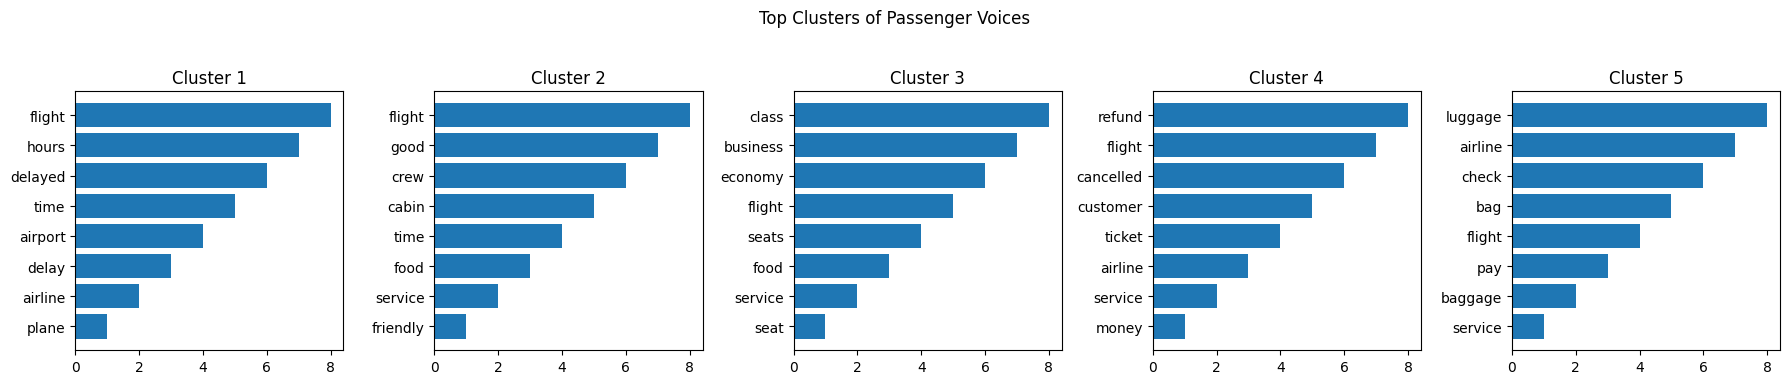


Average Sentiment Score per Review Cluster:


,sentiment_score
Review_Cluster,
0,-0.456994
1,0.546086
2,0.319167
3,-0.419254
4,-0.319783


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Load the dataset (assuming this is the original data load, if already loaded and processed, this might be redundant)
# file_path = 'Airline Review.csv'
# df = pd.read_csv(file_path)

# Clean column names (assuming this is needed for consistency)
# df.columns = [c.strip().replace(' ', '_') for c in df.columns]

# Ensure 'Review' column exists and handle missing values
if 'Review' not in df.columns:
    print("Error: 'Review' column not found in the DataFrame.")
else:
    # 1. Passenger satisfaction overview (already done in previous steps, keeping for context if needed)
    # plt.figure(figsize=(8,5))
    # sns.histplot(df['Overall_Rating'].dropna(), bins=10, kde=True)
    # plt.title('Distribution of Overall Ratings')
    # plt.xlabel('Overall Rating')
    # plt.ylabel('Number of Reviews')
    # plt.tight_layout()
    # plt.savefig('slide1_ratings.png')
    # plt.close()

    # Sentiment analysis (Add sentiment analysis here to ensure sentiment_score is available)
    try:
        nltk.data.find('sentiment/vader_lexicon.zip')
    except nltk.downloader.DownloadError:
        nltk.download('vader_lexicon')

    analyzer = SentimentIntensityAnalyzer()

    def get_sentiment_score(review):
        """Calculates the compound sentiment score for a given review."""
        if isinstance(review, str):
            return analyzer.polarity_scores(review)['compound']
        return None

    df['sentiment_score'] = df['Review'].apply(get_sentiment_score)

    # 3. Clustering Passenger Reviews (Text-based)
    print('Performing clustering analysis on passenger reviews...')
    reviews = df['Review'].fillna("")
    vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
    X = vectorizer.fit_transform(reviews)

    # Choose number of clusters (e.g., 5)
    k = 5
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    df['Review_Cluster'] = labels

    # Show top keywords for each cluster
    def get_top_keywords(cluster_num, n_terms=8):
        indices = np.where(labels == cluster_num)[0]
        mean_tfidf = np.mean(X[indices].toarray(), axis=0)
        top_indices = mean_tfidf.argsort()[::-1][:n_terms]
        return [vectorizer.get_feature_names_out()[i] for i in top_indices]

    cluster_keywords = {}
    for i in range(k):
        cluster_keywords[i] = get_top_keywords(i)
        print(f"Cluster {i+1}: {', '.join(cluster_keywords[i])}")

    # Visualize clusters (bar chart of top keywords per cluster)
    fig, axes = plt.subplots(1, k, figsize=(18, 4))
    for i in range(k):
        keywords = cluster_keywords[i]
        axes[i].barh(keywords[::-1], range(1, len(keywords)+1))
        axes[i].set_title(f'Cluster {i+1}')
    plt.suptitle('Top Clusters of Passenger Voices')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # plt.savefig('slide3_clusters.png') # Commenting out savefig to avoid saving plot automatically
    plt.show() # Display the plot instead of saving
    # plt.close() # No need to close if showing

    # print('Slide 3 visual saved: slide3_clusters.png')

    # Calculate and display average sentiment for each review cluster
    # if 'sentiment_score' in df.columns: # No need for this check after adding sentiment analysis above
    average_sentiment_per_cluster = df.groupby('Review_Cluster')['sentiment_score'].mean()
    print("\nAverage Sentiment Score per Review Cluster:")
    display(average_sentiment_per_cluster)
    # else:
    #     print("\n'sentiment_score' column not found. Please ensure sentiment analysis was performed.")

In [ ]:
print("Average Sentiment Score per Review Cluster:")
display(average_sentiment_per_cluster)

Average Sentiment Score per Review Cluster:


NameError: name 'average_sentiment_per_cluster' is not defined